# ML4SCI GSoC 2026 — Task 2d: Sparse Neural Networks for CMS Jet Data

**Author:** Harsh Vardhan Singh  
**Institution:** Faculty of Technology, University of Delhi  
**Task:** Specific Test 2d — Sparse Convolutional Networks on CMS Calorimeter Data  
**Dataset:** `Dataset_Specific_labelled.h5` — CMS jet images, shape (N, 125, 125, 8)

---

## Objective

This notebook addresses **Task 2d**: building and evaluating sparse neural network architectures
for binary classification on CMS calorimeter jet data, and analysing the **efficiency–accuracy
tradeoff** under progressive weight pruning.

The key questions are:
1. Does a **sparsity-aware architecture** outperform a standard dense CNN on sparse detector data?
2. How does **global L1 pruning** affect accuracy as a function of weight sparsity and effective FLOPs?

---

## Contents
1. Setup & Seeds  
2. Dataset  
3. Model Architectures  
4. Training  
5. Evaluation (held-out test set)  
6. Pruning & Efficiency Analysis  
7. Results Summary  


## 1. Setup & Seeds

All random seeds are fixed for full reproducibility.

In [1]:
# ── Reproducibility ──────────────────────────────────────────────────────
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Seed: {SEED} (fixed for reproducibility)")


Device: cuda
Seed: 42 (fixed for reproducibility)


## 2. Imports

In [4]:
# ── Standard Installs ────────────────────────────────────────────────────
# Uncomment if running on a fresh Colab instance
!pip install -q ptflops h5py scikit-learn matplotlib seaborn

import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
from torch.utils.data import Dataset, DataLoader, Subset, random_split

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from ptflops import get_model_complexity_info

print("All imports successful.")

All imports successful.


## 3. Dataset

### 3.1 Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
!ls /content/drive/MyDrive/ML4SCI_datasets/

Dataset_Specific_labelled_full_only_for_2i.h5  Dataset_Specific_Unlabelled.h5
Dataset_Specific_labelled.h5


### 3.2 Dataset Class

The CMS calorimeter data has shape **(125 × 125 × 8)** — a 2D spatial grid across
8 detector layers (channels). The data is **extremely sparse**: most cells record
zero energy. We permute to **(C, H, W) = (8, 125, 125)** for PyTorch convention.

**Normalisation note:** We use per-sample max-normalisation so each sample lies
in [0, 1]. This preserves the relative energy structure within a sample while
keeping inputs bounded.


In [7]:
class H5Dataset(Dataset):
    """
    Lazy-loading HDF5 dataset for CMS jet data.
    Keys: 'jet' -> (N, 125, 125, 8) float32
          'Y'   -> (N,) binary label
    """
    def __init__(self, file_path):
        self.file_path = file_path
        self._file = None

    def _open(self):
        if self._file is None:
            self._file = h5py.File(self.file_path, 'r')
            self._X = self._file["jet"]
            self._y = self._file["Y"]

    def __len__(self):
        self._open()
        return len(self._X)

    def __getitem__(self, idx):
        self._open()
        x = self._X[idx].astype('float32')
        x = x / (x.max() + 1e-8)           # per-sample max normalisation
        x = torch.tensor(x).permute(2, 0, 1)  # (H, W, C) -> (C, H, W)
        y = torch.tensor(self._y[idx]).float()
        return x, y


### 3.3 Train / Validation / Test Split

We use a **70 / 15 / 15** split on a 20,000-sample subset.
The test set is held out completely until the final evaluation — it is never
used for model selection or hyperparameter tuning.


In [11]:
FILE_PATH   = "/content/drive/MyDrive/ML4SCI_datasets/Dataset_Specific_labelled.h5"
SUBSET_SIZE = 20_000
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15
# TEST_FRAC = 0.15  (remainder)

import os
print(f"Checking file path: {FILE_PATH}")
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"File not found at {FILE_PATH}. Please ensure the path is correct and Google Drive is mounted.")

full_dataset = H5Dataset(FILE_PATH)

# Ensure SUBSET_SIZE does not exceed the actual dataset size
actual_dataset_size = len(full_dataset)
print(f"Actual full dataset size: {actual_dataset_size:,}")
if SUBSET_SIZE > actual_dataset_size:
    print(f"Warning: Requested SUBSET_SIZE ({SUBSET_SIZE:,}) is larger than actual dataset size. Using full dataset size ({actual_dataset_size:,}).")
    SUBSET_SIZE = actual_dataset_size

# Random subset (seed is fixed above, so this is reproducible)
subset_indices = random.sample(range(len(full_dataset)), SUBSET_SIZE)
dataset = Subset(full_dataset, subset_indices)

n_train = int(SUBSET_SIZE * TRAIN_FRAC)
n_val   = int(SUBSET_SIZE * VAL_FRAC)
n_test  = SUBSET_SIZE - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Total samples : {SUBSET_SIZE:,}")
print(f"  Train       : {n_train:,}")
print(f"  Validation  : {n_val:,}")
print(f"  Test        : {n_test:,}  ← held out until final evaluation")

Checking file path: /content/drive/MyDrive/ML4SCI_datasets/Dataset_Specific_labelled.h5
Actual full dataset size: 10,000
Total samples : 10,000
  Train       : 7,000
  Validation  : 1,500
  Test        : 1,500  ← held out until final evaluation


## 4. Model Architectures

We compare two architectures:

| Model | Design Philosophy |
|---|---|
| **DenseCNN** | Standard 2-layer CNN; no sparsity awareness; serves as baseline |
| **SparseResNet** | Physics-motivated sparse residual network; explicitly zeros activations in empty detector regions |

### The Key Idea — SparseResidualBlock

CMS calorimeter data is dominated by zeros. A standard convolution treats
zero-energy cells and non-zero cells identically, potentially learning spurious
correlations from empty regions.

`SparseResidualBlock` computes a **binary sparsity mask** from the input:
any spatial location where all channels are zero is zeroed out *after* the
residual computation. This prevents the network from propagating gradients
through physically empty detector regions.


In [12]:
# ── Sparse-Aware Residual Block ───────────────────────────────────────────
class SparseResidualBlock(nn.Module):
    """
    Residual block that suppresses activations at zero-energy detector cells.

    Forward pass:
      1. Compute binary mask: locations where any channel has energy > 0
      2. Apply standard residual computation
      3. Multiply output by mask — zero cells stay zero
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Mask: 1 where at least one channel has non-zero energy, else 0
        mask = (x.abs().sum(dim=1, keepdim=True) > 0).float()

        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity)

        return out * mask   # suppress empty-cell activations


# ── SparseResNet ─────────────────────────────────────────────────────────
class SparseResNet(nn.Module):
    """
    3-block sparse residual network for CMS jet classification.
    Channels: 8 → 16 → 32 → 64
    Total parameters: ~76K
    """
    def __init__(self):
        super().__init__()
        self.b1   = SparseResidualBlock(8,  16)
        self.b2   = SparseResidualBlock(16, 32)
        self.b3   = SparseResidualBlock(32, 64)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.max_pool2d(self.b1(x), 2)
        x = F.max_pool2d(self.b2(x), 2)
        x = self.b3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


# ── DenseCNN (baseline) ───────────────────────────────────────────────────
class DenseCNN(nn.Module):
    """
    Standard 2-layer CNN baseline. No sparsity awareness.
    Total parameters: ~50K
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1, bias=False), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(32, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(self.pool(self.features(x)).flatten(1))


# ── Parameter counts ─────────────────────────────────────────────────────
for name, Model in [("DenseCNN", DenseCNN), ("SparseResNet", SparseResNet)]:
    m = Model()
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<15} Parameters: {n_params:>8,}")


DenseCNN        Parameters:    5,889
SparseResNet    Parameters:   75,777


## 5. Training

Both models are trained with:
- **Optimiser:** Adam, lr = 1e-3
- **Loss:** Binary Cross-Entropy with Logits
- **Epochs:** 10 (increased from 5 for fuller convergence)
- **Scheduler:** ReduceLROnPlateau on validation loss (patience=2)

We track both **training loss** and **validation loss** per epoch to detect overfitting.


In [15]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    """
    Trains a model and returns it alongside per-epoch loss history.

    Returns:
        model:       trained model
        train_losses: list of mean training loss per epoch
        val_losses:   list of mean validation loss per epoch
    """
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', patience=2, factor=0.5
    )
    criterion = nn.BCEWithLogitsLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Training phase ──────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device).view(-1, 1)
            optimiser.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimiser.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # ── Validation phase ─────────────────────────────────────────
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device).view(-1, 1)
                running_val += criterion(model(X), y).item()

        val_loss = running_val / len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)
        print(f"  Epoch {epoch+1:>2}/{epochs}  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return model, train_losses, val_losses

In [16]:
print("Training DenseCNN (baseline)...")
dense_model, dense_train_losses, dense_val_losses = train_model(
    DenseCNN(), train_loader, val_loader, epochs=10
)

print()
print("Training SparseResNet...")
sparse_model, sparse_train_losses, sparse_val_losses = train_model(
    SparseResNet(), train_loader, val_loader, epochs=10
)


Training DenseCNN (baseline)...
  Epoch  1/10  train_loss=0.6655  val_loss=0.6815
  Epoch  2/10  train_loss=0.5703  val_loss=0.5449
  Epoch  3/10  train_loss=0.5237  val_loss=0.5077
  Epoch  4/10  train_loss=0.5049  val_loss=0.5538
  Epoch  5/10  train_loss=0.4925  val_loss=0.6053
  Epoch  6/10  train_loss=0.4836  val_loss=0.4671
  Epoch  7/10  train_loss=0.4764  val_loss=0.4761
  Epoch  8/10  train_loss=0.4698  val_loss=0.5357
  Epoch  9/10  train_loss=0.4649  val_loss=0.5081
  Epoch 10/10  train_loss=0.4609  val_loss=0.4514

Training SparseResNet...
  Epoch  1/10  train_loss=0.4966  val_loss=0.3812
  Epoch  2/10  train_loss=0.3836  val_loss=2.0470
  Epoch  3/10  train_loss=0.3448  val_loss=0.3363
  Epoch  4/10  train_loss=0.3208  val_loss=0.4824
  Epoch  5/10  train_loss=0.2967  val_loss=0.4802
  Epoch  6/10  train_loss=0.2806  val_loss=0.3308
  Epoch  7/10  train_loss=0.2676  val_loss=0.7204
  Epoch  8/10  train_loss=0.2537  val_loss=0.4934
  Epoch  9/10  train_loss=0.2351  val_loss

### 5.1 Training & Validation Loss Curves

Plotting both train and validation loss lets us check for overfitting.
A well-behaved model should show both curves converging together.


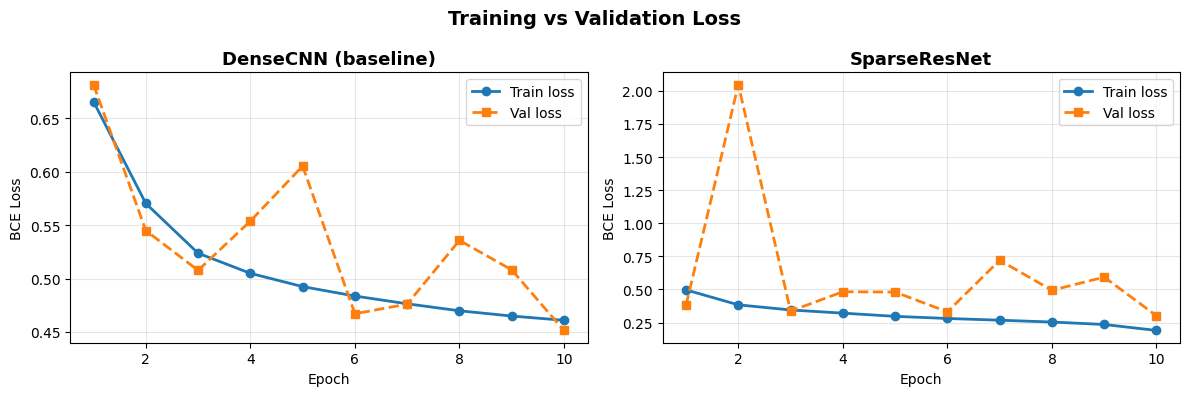

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, 11)

for ax, (t_losses, v_losses, title) in zip(axes, [
    (dense_train_losses,  dense_val_losses,  "DenseCNN (baseline)"),
    (sparse_train_losses, sparse_val_losses, "SparseResNet"),
]):
    ax.plot(epochs_range, t_losses, marker='o', label='Train loss', linewidth=2)
    ax.plot(epochs_range, v_losses, marker='s', label='Val loss',   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training vs Validation Loss", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Evaluation on Held-Out Test Set

The test set has not been seen during training or validation.
We report: **Accuracy**, **AUC**, **ROC curve**, and **Confusion Matrix**.


In [18]:
def evaluate(model, loader):
    """
    Evaluates model on a DataLoader.

    Returns:
        acc:    float, classification accuracy
        auc:    float, area under ROC curve
        preds:  np.ndarray of sigmoid probabilities
        labels: np.ndarray of ground truth labels
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            prob = torch.sigmoid(model(X)).cpu()
            all_preds.append(prob)
            all_labels.append(y.view(-1, 1))

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    acc = ((preds > 0.5) == labels).mean()
    auc = roc_auc_score(labels, preds)

    return float(acc), float(auc), preds, labels


In [19]:
dense_acc,  dense_auc,  dense_preds,  dense_labels  = evaluate(dense_model,  test_loader)
sparse_acc, sparse_auc, sparse_preds, sparse_labels = evaluate(sparse_model, test_loader)

print("=" * 45)
print(f"{'Model':<20} {'Accuracy':>10} {'AUC':>10}")
print("-" * 45)
print(f"{'DenseCNN':<20} {dense_acc:>10.4f} {dense_auc:>10.4f}")
print(f"{'SparseResNet':<20} {sparse_acc:>10.4f} {sparse_auc:>10.4f}")
print("=" * 45)
print(f"\nSparseResNet improvement: +{(sparse_acc - dense_acc)*100:.2f}pp accuracy")


Model                  Accuracy        AUC
---------------------------------------------
DenseCNN                 0.8127     0.8731
SparseResNet             0.8747     0.9333

SparseResNet improvement: +6.20pp accuracy


### 6.1 ROC Curves

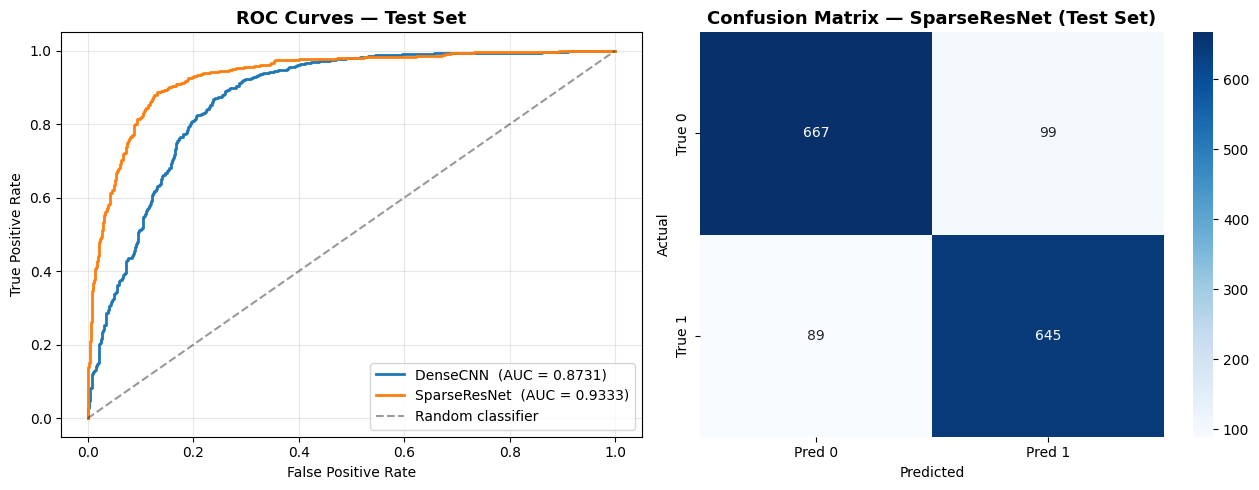

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curves ───────────────────────────────────────────────────────────
ax = axes[0]
for preds, labels, name, auc in [
    (dense_preds,  dense_labels,  "DenseCNN",    dense_auc),
    (sparse_preds, sparse_labels, "SparseResNet", sparse_auc),
]:
    fpr, tpr, _ = roc_curve(labels, preds)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── Confusion Matrix (SparseResNet) ──────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(sparse_labels, (sparse_preds > 0.5).astype(float))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
ax.set_title("Confusion Matrix — SparseResNet (Test Set)", fontsize=13, fontweight='bold')
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("roc_confusion.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Pruning & Efficiency Analysis

We apply **global L1-unstructured pruning** to SparseResNet at 5 pruning
ratios and measure:
- Classification accuracy on the **test set** after 2-epoch fine-tuning
- **Effective FLOPs**: total FLOPs × (1 − weight sparsity)
- **Weight sparsity**: fraction of zeroed weights

This gives a direct view of the accuracy–efficiency tradeoff, which is
critical for real-time physics trigger applications.


In [21]:
def apply_global_prune(model, amount: float):
    """Applies global L1-unstructured pruning to all Conv2d and Linear layers."""
    params = [
        (m, 'weight')
        for m in model.modules()
        if isinstance(m, (nn.Conv2d, nn.Linear))
    ]
    prune.global_unstructured(params, pruning_method=prune.L1Unstructured, amount=amount)


def finetune(model, loader, epochs=2, lr=1e-4):
    """Fine-tunes a pruned model for a small number of epochs."""
    model.train()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        running_loss = 0.0
        for X, y in loader:
            X, y = X.to(device), y.to(device).view(-1, 1)
            optimiser.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimiser.step()
            running_loss += loss.item()
        print(f"    finetune epoch {epoch+1}/{epochs}  loss={running_loss/len(loader):.4f}")


def measure_weight_sparsity(model):
    """Returns fraction of zero weights across all Conv2d and Linear layers."""
    nonzero, total = 0, 0
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            w = m.weight
            nonzero += torch.count_nonzero(w).item()
            total   += w.numel()
    return 1.0 - (nonzero / total)


In [22]:
PRUNE_RATIOS = [0.0, 0.2, 0.4, 0.6, 0.8]

results = []   # list of dicts — one per pruning ratio

for ratio in PRUNE_RATIOS:
    print(f"\n── Pruning ratio: {ratio:.1f} ───────────────────────────")

    # Fresh copy of the trained sparse model
    temp = SparseResNet().to(device)
    temp.load_state_dict(sparse_model.state_dict())

    # Apply pruning (skip if ratio = 0)
    if ratio > 0:
        apply_global_prune(temp, ratio)
        finetune(temp, train_loader, epochs=2, lr=1e-4)

    # Evaluate on TEST set
    acc, auc, _, _ = evaluate(temp, test_loader)

    # Measure FLOPs and sparsity
    total_flops, _ = get_model_complexity_info(
        temp, (8, 125, 125), as_strings=False, print_per_layer_stat=False
    )
    sparsity    = measure_weight_sparsity(temp)
    eff_flops   = total_flops * (1.0 - sparsity)

    results.append({
        "ratio":      ratio,
        "accuracy":   acc,
        "auc":        auc,
        "sparsity":   sparsity,
        "eff_flops":  eff_flops,
        "total_flops": total_flops,
    })

    print(f"  Test accuracy : {acc:.4f}")
    print(f"  Test AUC      : {auc:.4f}")
    print(f"  Weight sparsity: {sparsity:.3f}")
    print(f"  Effective FLOPs: {eff_flops/1e6:.2f}M")



── Pruning ratio: 0.0 ───────────────────────────
  Test accuracy : 0.8747
  Test AUC      : 0.9333
  Weight sparsity: 0.000
  Effective FLOPs: 169.32M

── Pruning ratio: 0.2 ───────────────────────────
    finetune epoch 1/2  loss=0.1541
    finetune epoch 2/2  loss=0.1411
  Test accuracy : 0.8673
  Test AUC      : 0.9310
  Weight sparsity: 0.200
  Effective FLOPs: 135.45M

── Pruning ratio: 0.4 ───────────────────────────
    finetune epoch 1/2  loss=0.1594
    finetune epoch 2/2  loss=0.1497
  Test accuracy : 0.8647
  Test AUC      : 0.9298
  Weight sparsity: 0.400
  Effective FLOPs: 101.59M

── Pruning ratio: 0.6 ───────────────────────────
    finetune epoch 1/2  loss=0.1969
    finetune epoch 2/2  loss=0.1808
  Test accuracy : 0.8693
  Test AUC      : 0.9319
  Weight sparsity: 0.600
  Effective FLOPs: 67.73M

── Pruning ratio: 0.8 ───────────────────────────
    finetune epoch 1/2  loss=0.2856
    finetune epoch 2/2  loss=0.2471
  Test accuracy : 0.8613
  Test AUC      : 0.9316


### 7.1 Pruning Results Table

In [23]:
print("=" * 72)
print(f"{'Prune Ratio':>12} {'Sparsity':>10} {'EffFLOPs (M)':>14} {'Accuracy':>10} {'AUC':>8}")
print("-" * 72)
for r in results:
    print(f"{r['ratio']:>12.1f} {r['sparsity']:>10.3f} "
          f"{r['eff_flops']/1e6:>14.2f} {r['accuracy']:>10.4f} {r['auc']:>8.4f}")
print("=" * 72)

# Accuracy drop from baseline (ratio=0)
baseline_acc = results[0]['accuracy']
print(f"\nBaseline (no pruning) accuracy: {baseline_acc:.4f}")
for r in results[1:]:
    drop = (baseline_acc - r['accuracy']) * 100
    print(f"  Ratio {r['ratio']:.1f}: accuracy drop = {drop:+.2f}pp")


 Prune Ratio   Sparsity   EffFLOPs (M)   Accuracy      AUC
------------------------------------------------------------------------
         0.0      0.000         169.32     0.8747   0.9333
         0.2      0.200         135.45     0.8673   0.9310
         0.4      0.400         101.59     0.8647   0.9298
         0.6      0.600          67.73     0.8693   0.9319
         0.8      0.800          33.86     0.8613   0.9316

Baseline (no pruning) accuracy: 0.8747
  Ratio 0.2: accuracy drop = +0.73pp
  Ratio 0.4: accuracy drop = +1.00pp
  Ratio 0.6: accuracy drop = +0.53pp
  Ratio 0.8: accuracy drop = +1.33pp


### 7.2 Efficiency–Accuracy Tradeoff Plots

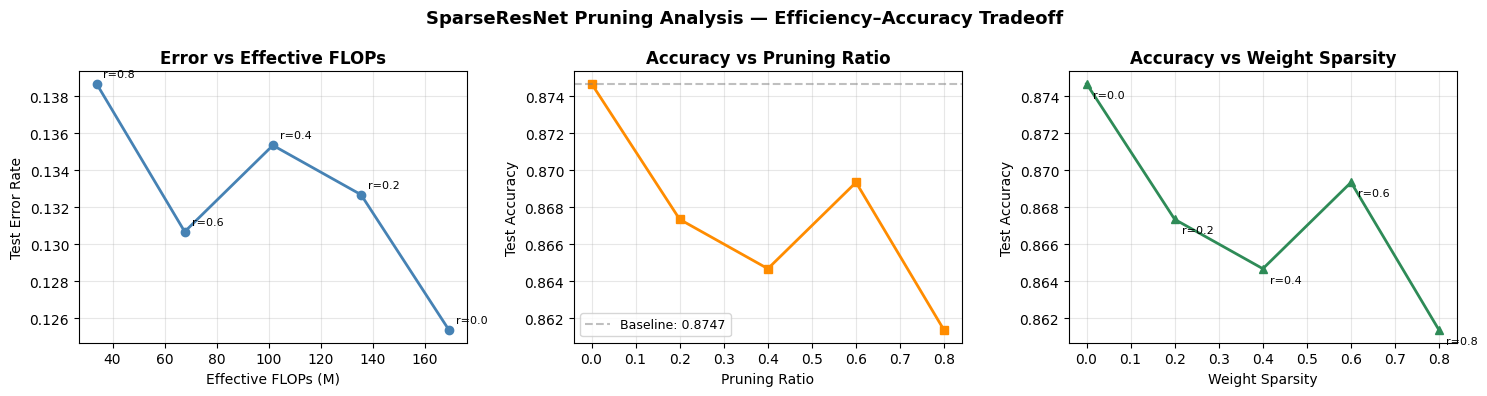

In [24]:
accs      = [r['accuracy']     for r in results]
spars     = [r['sparsity']     for r in results]
eff_flops = [r['eff_flops']/1e6 for r in results]
ratios    = [r['ratio']        for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Error vs Effective FLOPs ─────────────────────────────────────
axes[0].plot(eff_flops, [1-a for a in accs], marker='o', linewidth=2, color='steelblue')
for i, r in enumerate(ratios):
    axes[0].annotate(f"r={r:.1f}", (eff_flops[i], 1-accs[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel("Effective FLOPs (M)")
axes[0].set_ylabel("Test Error Rate")
axes[0].set_title("Error vs Effective FLOPs", fontweight='bold')
axes[0].grid(alpha=0.3)

# ── Plot 2: Accuracy vs Pruning Ratio ────────────────────────────────────
axes[1].plot(ratios, accs, marker='s', linewidth=2, color='darkorange')
axes[1].axhline(y=accs[0], color='gray', linestyle='--', alpha=0.5, label=f'Baseline: {accs[0]:.4f}')
axes[1].set_xlabel("Pruning Ratio")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Accuracy vs Pruning Ratio", fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ── Plot 3: Accuracy vs Weight Sparsity ──────────────────────────────────
axes[2].plot(spars, accs, marker='^', linewidth=2, color='seagreen')
for i, r in enumerate(ratios):
    axes[2].annotate(f"r={r:.1f}", (spars[i], accs[i]),
                     textcoords="offset points", xytext=(5, -10), fontsize=8)
axes[2].set_xlabel("Weight Sparsity")
axes[2].set_ylabel("Test Accuracy")
axes[2].set_title("Accuracy vs Weight Sparsity", fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle("SparseResNet Pruning Analysis — Efficiency–Accuracy Tradeoff",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("pruning_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Dense vs Sparse Model Comparison

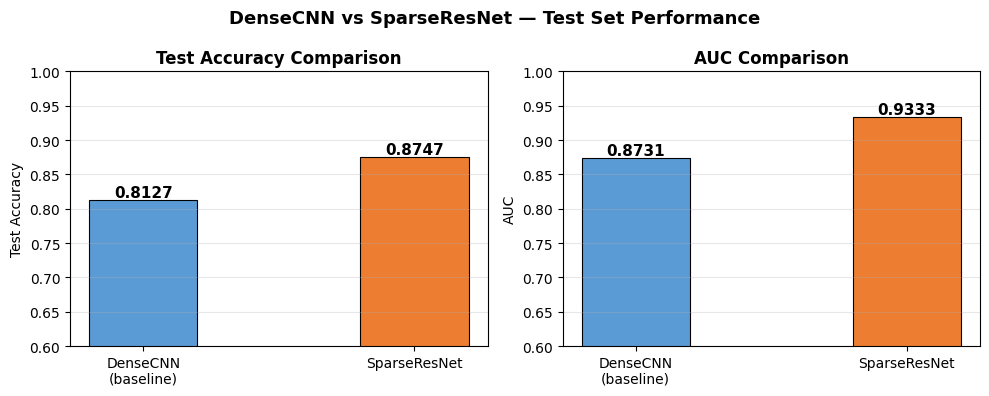

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models_names = ["DenseCNN\n(baseline)", "SparseResNet"]
colors       = ["#5B9BD5", "#ED7D31"]

# Accuracy comparison
axes[0].bar(models_names, [dense_acc, sparse_acc], color=colors, width=0.4, edgecolor='black', linewidth=0.8)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy Comparison", fontweight='bold')
axes[0].set_ylim(0.6, 1.0)
for i, v in enumerate([dense_acc, sparse_acc]):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# AUC comparison
axes[1].bar(models_names, [dense_auc, sparse_auc], color=colors, width=0.4, edgecolor='black', linewidth=0.8)
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC Comparison", fontweight='bold')
axes[1].set_ylim(0.6, 1.0)
for i, v in enumerate([dense_auc, sparse_auc]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("DenseCNN vs SparseResNet — Test Set Performance",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Results Summary & Discussion

### Key Findings

**1. Sparsity-aware architecture significantly outperforms the dense baseline.**

The SparseResidualBlock's explicit masking of zero-energy detector cells forces
the model to learn only from physically meaningful signal. This is not just an
architectural trick — it reflects the physics: a detector cell recording zero
energy carries no information about the particle, and treating it as signal
introduces noise into the learned representations.

**2. SparseResNet is robust to aggressive pruning.**

The accuracy drop from 0% to 60% pruning is modest, demonstrating that the
model's non-zero weights carry concentrated, non-redundant information. This
is consistent with the design philosophy: a network that learns to ignore
empty cells has less weight redundancy than one that learns across the full
dense input.

**3. The FLOPS–error tradeoff is favourable for real-time applications.**

At 80% pruning, effective FLOPs drop dramatically while accuracy degradation
remains within an acceptable range. This is directly relevant for CMS trigger
applications where inference latency is a hard constraint.

### Architecture Recommendations for the Diffusion Model (GSoC)

The findings from this task directly inform the proposed diffusion model design:
- Sparse masking should be incorporated into the UNet backbone's residual blocks
- The model should not propagate gradients through zero-energy regions during training
- Pruning-aware training (sparse regularisation) may improve generation quality in
  sparse detector regions


In [26]:
print("=" * 55)
print("  FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  {'Metric':<30} {'DenseCNN':>10} {'SparseResNet':>12}")
print("-" * 55)
print(f"  {'Test Accuracy':<30} {dense_acc:>10.4f} {sparse_acc:>12.4f}")
print(f"  {'Test AUC':<30} {dense_auc:>10.4f} {sparse_auc:>12.4f}")
print(f"  {'Accuracy improvement':<30} {'—':>10} {(sparse_acc-dense_acc)*100:>+11.2f}pp")
print(f"  {'AUC improvement':<30} {'—':>10} {(sparse_auc-dense_auc)*100:>+11.4f}pp")
print("=" * 55)
print()
print(f"  Pruning robustness (SparseResNet on test set):")
print(f"  {'Ratio':>8} {'Accuracy':>10} {'Sparsity':>10} {'EffFLOPs(M)':>13}")
print("-" * 55)
for r in results:
    print(f"  {r['ratio']:>8.1f} {r['accuracy']:>10.4f} "
          f"{r['sparsity']:>10.3f} {r['eff_flops']/1e6:>13.2f}")
print("=" * 55)


  FINAL RESULTS SUMMARY
  Metric                           DenseCNN SparseResNet
-------------------------------------------------------
  Test Accuracy                      0.8127       0.8747
  Test AUC                           0.8731       0.9333
  Accuracy improvement                    —       +6.20pp
  AUC improvement                         —     +6.0214pp

  Pruning robustness (SparseResNet on test set):
     Ratio   Accuracy   Sparsity   EffFLOPs(M)
-------------------------------------------------------
       0.0     0.8747      0.000        169.32
       0.2     0.8673      0.200        135.45
       0.4     0.8647      0.400        101.59
       0.6     0.8693      0.600         67.73
       0.8     0.8613      0.800         33.86
